# MKDT CIFAR-10 — Visualisations & Tableaux



In [3]:
from google.colab import drive
drive.mount('/content/drive')
import os
PERSIST = "/content/drive/MyDrive/mkdt_project"
OUT = f"{PERSIST}/outputs_viz"; os.makedirs(OUT, exist_ok=True)
print("Sorties :", OUT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Sorties : /content/drive/MyDrive/mkdt_project/outputs_viz


In [4]:
import os, glob
print("Contenu de PERSIST :")
for f in sorted(glob.glob(f"{PERSIST}/*")): print("  ", os.path.basename(f))
print("CSV de résultats trouvés :")
for f in sorted(glob.glob(f"{PERSIST}/results_*.csv")): print("  ", os.path.basename(f))
print("Runs distillés trouvés :")
for loc in [f"{PERSIST}/logged_files/CIFAR10", "/content/MKDT/logged_files/CIFAR10"]:
    for r in sorted(glob.glob(f"{loc}/*")):
        imgs = glob.glob(f"{r}/images_*.pt")
        print(f"  {r}  ->  {len(imgs)} fichier(s) images")

Contenu de PERSIST :
   buffers_barlow_twins
   krrst_teacher_ckpt
   logged_files
   outputs_viz
   results_fulldata.csv
   results_mkdt.csv
   results_nopretrain.csv
   results_random.csv
   target_rep
CSV de résultats trouvés :
   results_fulldata.csv
   results_mkdt.csv
   results_nopretrain.csv
   results_random.csv
Runs distillés trouvés :


## Données de l'article

In [5]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
DOWNSTREAM=["CIFAR10","TinyImageNet","CIFAR100","Aircraft","CUB2011","Dogs","Flowers"]
METHODS=["No Pre-Training","Random Subset","SAS Subset","KRR-ST","MKDT","Full Data"]
TABLE1={"1%":{"No Pre-Training":[35.84,2.52,8.01,2.43,1.27,1.92,2.02],"Random Subset":[36.35,2.41,7.42,2.41,1.16,1.90,1.99],
              "SAS Subset":[36.02,2.69,7.77,2.29,1.14,1.78,2.22],"KRR-ST":[37.19,2.84,8.67,2.53,1.25,1.88,2.42],
              "MKDT":[44.36,3.58,10.58,2.58,1.37,2.11,2.52],"Full Data":[58.21,4.94,14.53,2.92,1.69,2.40,3.23]},
        "5%":{"No Pre-Training":[46.23,5.37,16.12,5.61,1.97,2.90,5.22],"Random Subset":[46.62,5.49,15.28,5.35,1.51,2.52,3.64],
              "SAS Subset":[46.52,5.41,15.90,5.63,1.48,2.69,3.75],"KRR-ST":[46.75,6.85,16.65,5.41,1.88,2.76,4.52],
              "MKDT":[53.08,7.25,19.57,5.97,2.06,3.06,4.97],"Full Data":[67.16,10.85,26.38,6.92,2.51,3.88,6.37]}}
CIFAR10_STD={"1%":{"No Pre-Training":1.39,"Random Subset":0.67,"SAS Subset":1.52,"KRR-ST":0.49,"MKDT":1.61,"Full Data":0.28},
             "5%":{"No Pre-Training":0.07,"Random Subset":1.02,"SAS Subset":0.61,"KRR-ST":0.45,"MKDT":0.13,"Full Data":0.43}}
CIFAR10_MEAN=np.array([0.4914,0.4822,0.4465]); CIFAR10_STD_IMG=np.array([0.2023,0.1994,0.2010])

def parse_acc(v):
    try: return float(v)
    except Exception:
        import re
        m=re.search(r"[-+]?\d+\.?\d*", str(v))
        return float(m.group()) if m else None
print("OK")

OK


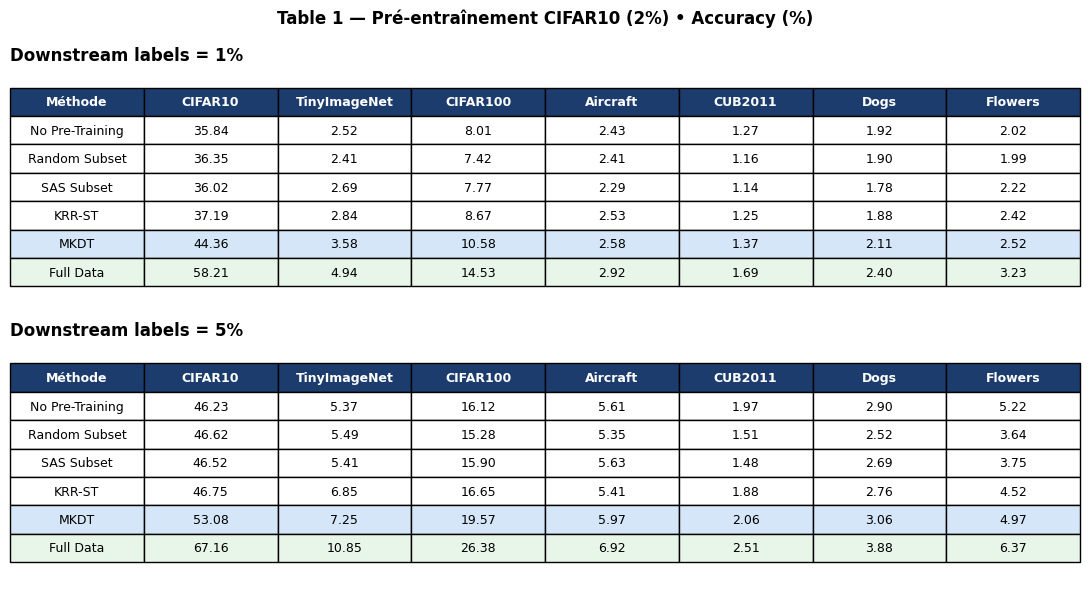

[ok] table + figure sauvegardées


In [6]:
try:
    frames=[]
    for frac in ["1%","5%"]:
        df=pd.DataFrame(TABLE1[frac],index=DOWNSTREAM).T; df.insert(0,"Labels",frac); frames.append(df)
    full=pd.concat(frames); full.index.name="Méthode"
    full.to_csv(f"{OUT}/table1_cifar10.csv")
    open(f"{OUT}/table1_cifar10.md","w").write("# Table 1 — CIFAR10 (2%)\n\n"+full.to_markdown())
    fig,axes=plt.subplots(2,1,figsize=(11,6))
    for ax,frac in zip(axes,["1%","5%"]):
        data=[[m]+[f"{v:.2f}" for v in TABLE1[frac][m]] for m in METHODS]
        t=ax.table(cellText=data,colLabels=["Méthode"]+DOWNSTREAM,loc="center",cellLoc="center")
        t.auto_set_font_size(False); t.set_fontsize(9); t.scale(1,1.5)
        for (r,c),cell in t.get_celld().items():
            if r==0: cell.set_facecolor("#1d3c6e"); cell.set_text_props(color="white",weight="bold")
            elif METHODS[r-1]=="MKDT": cell.set_facecolor("#d4e6f7")
            elif METHODS[r-1]=="Full Data": cell.set_facecolor("#e8f5e9")
        ax.axis("off"); ax.set_title(f"Downstream labels = {frac}",fontweight="bold",loc="left")
    fig.suptitle("Table 1 — Pré-entraînement CIFAR10 (2%) • Accuracy (%)",fontweight="bold")
    fig.tight_layout(); fig.savefig(f"{OUT}/fig_table1_cifar10.png",dpi=150,bbox_inches="tight"); plt.show()
    print("[ok] table + figure sauvegardées")
except Exception as e:
    print("[erreur table1] :", e)

## Bar plot des méthodes

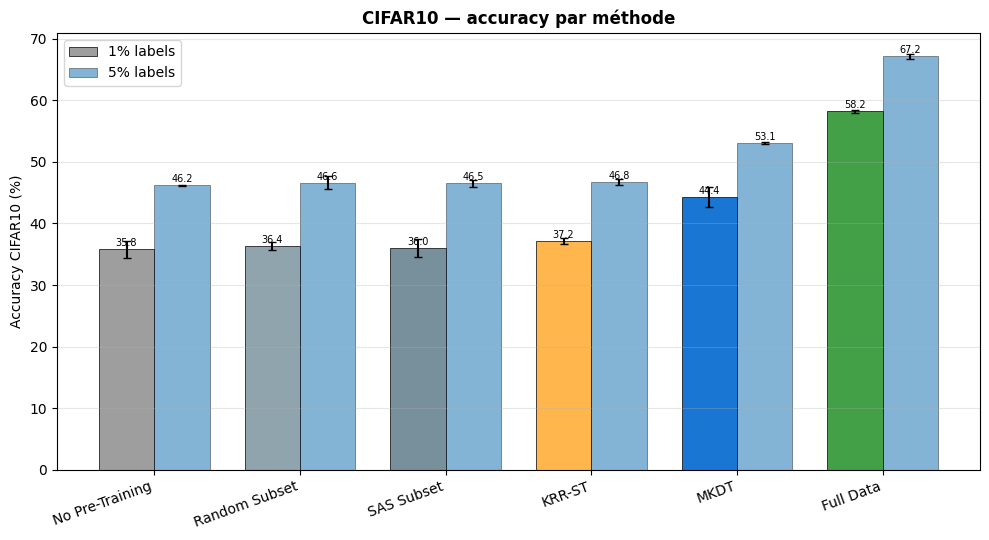

[ok] bar plot sauvegardé


In [8]:
try:
    x=np.arange(len(METHODS)); w=0.38
    colors=["#9e9e9e","#90a4ae","#78909c","#ffb74d","#1976d2","#43a047"]
    fig,ax=plt.subplots(figsize=(10,5.5))
    for i,frac in enumerate(["1%","5%"]):
        vals=[TABLE1[frac][m][0] for m in METHODS]; errs=[CIFAR10_STD[frac][m] for m in METHODS]
        bars=ax.bar(x+(i-0.5)*w,vals,w,yerr=errs,capsize=3,label=f"{frac} labels",
                    color=colors if i==0 else None,alpha=1 if i==0 else .55,edgecolor="black",linewidth=.5)
        for b,v in zip(bars,vals): ax.text(b.get_x()+b.get_width()/2,v+.5,f"{v:.1f}",ha="center",fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels(METHODS,rotation=20,ha="right"); ax.set_ylabel("Accuracy CIFAR10 (%)")
    ax.set_title("CIFAR10 — accuracy par méthode",fontweight="bold")
    ax.legend(); ax.grid(axis="y",alpha=.3); fig.tight_layout()
    fig.savefig(f"{OUT}/fig_cifar10_barplot.png",dpi=150,bbox_inches="tight"); plt.show()
    print("[ok] bar plot sauvegardé")
except Exception as e:
    print("[erreur barplot] :", e)

## Grille des images distillées


Images utilisees : /content/drive/MyDrive/mkdt_project/logged_files/2026-06-15_13:45:24None/images_5000.pt


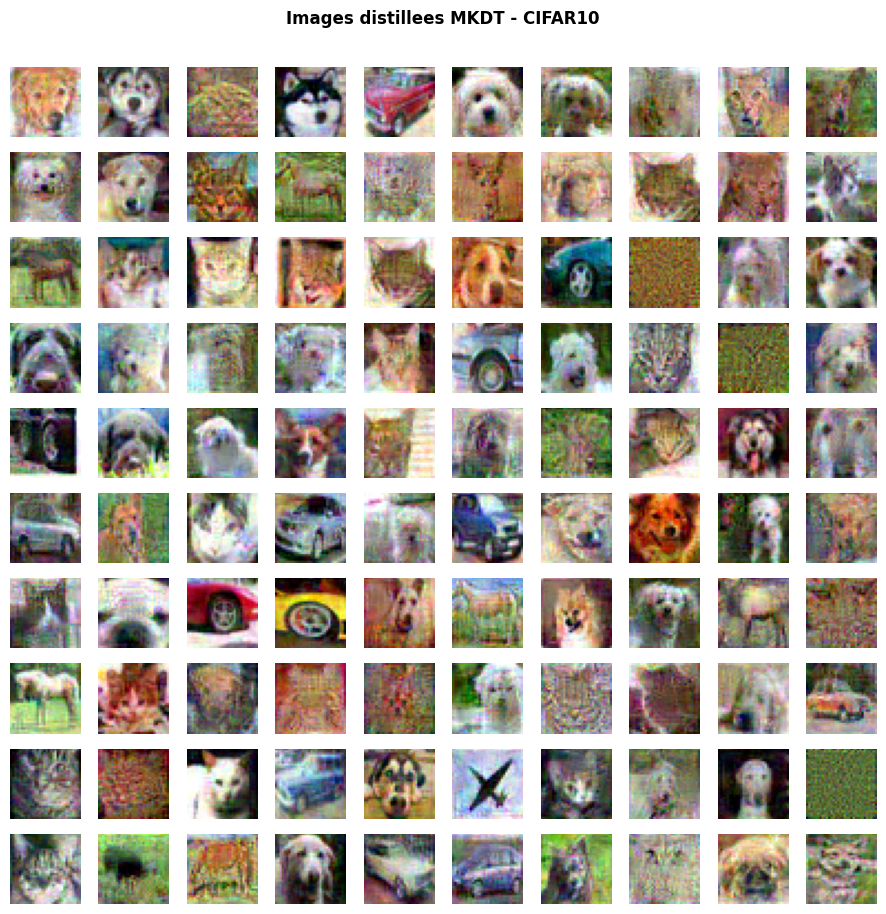

[ok] grille sauvegardee (100 images)


In [9]:
import re, glob, os
def find_images():
    cands=[]
    locs = [f"{PERSIST}/logged_files",
            f"{PERSIST}/logged_files/CIFAR10",
            "/content/MKDT/logged_files",
            "/content/MKDT/logged_files/CIFAR10"]
    for loc in locs:
        for r in glob.glob(f"{loc}/*"):
            for p in glob.glob(f"{r}/images_*.pt"):
                m=re.search(r"images_(\d+)\.pt", os.path.basename(p))
                it=int(m.group(1)) if m else -1
                cands.append((it, os.path.getmtime(p), p))
    cands.sort(key=lambda c:(c[0], c[1]))
    return cands[-1][2] if cands else None

try:
    path=find_images()
    if path is None:
        print("Aucun fichier images_*.pt trouve.")
    else:
        print("Images utilisees :", path)
        import torch
        x=torch.load(path, map_location="cpu", weights_only=False).detach().numpy()
        n=min(100, x.shape[0])
        g=x[:n].transpose(0,2,3,1)*CIFAR10_STD_IMG+CIFAR10_MEAN; g=np.clip(g,0,1)
        ncol=10; nrow=int(np.ceil(n/ncol))
        fig,axes=plt.subplots(nrow,ncol,figsize=(ncol*0.9,nrow*0.9))
        for i,ax in enumerate(np.array(axes).flat):
            if i<n: ax.imshow(g[i])
            ax.axis("off")
        fig.suptitle("Images distillees MKDT - CIFAR10",fontweight="bold",y=1.01)
        fig.tight_layout(); fig.savefig(f"{OUT}/fig_distilled_images.png",dpi=150,bbox_inches="tight"); plt.show()
        print(f"[ok] grille sauvegardee ({n} images)")
except Exception as e:
    print("[erreur grille] :", e)

## Mes résultats vs Article

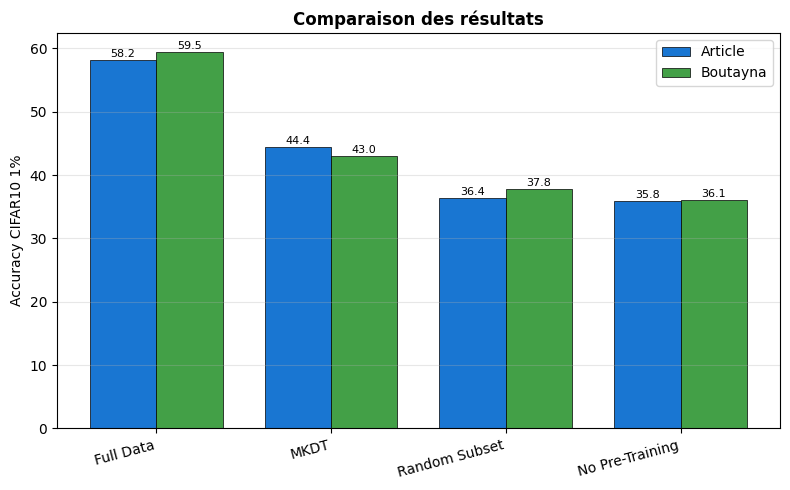

[ok] comparatif sauvegardé
        Méthode  Article   Boutayna
      Full Data     58.21     59.49
           MKDT     44.36     43.02
  Random Subset     36.35     37.84
No Pre-Training     35.84     36.11


In [11]:
try:
    papier={"Full Data":58.21,"MKDT":44.36,"Random Subset":36.35,"No Pre-Training":35.84}
    files={"Full Data":"results_fulldata.csv","MKDT":"results_mkdt.csv",
           "Random Subset":"results_random.csv","No Pre-Training":"results_nopretrain.csv"}
    rows=[]
    for m,f in files.items():
        p=f"{PERSIST}/{f}"
        if os.path.exists(p):
            v=parse_acc(pd.read_csv(p).iloc[-1].get("CIFAR10",None))
            rows.append((m,papier.get(m,np.nan),v))
    if not rows:
        print("Aucun CSV de résultats (Full Data / MKDT).")
    else:
        labels=[r[0] for r in rows]; pap=[r[1] for r in rows]; obt=[r[2] for r in rows]
        x=np.arange(len(labels)); w=.38
        fig,ax=plt.subplots(figsize=(8,5))
        ax.bar(x-w/2,pap,w,label="Article",color="#1976d2",edgecolor="black",linewidth=.5)
        ax.bar(x+w/2,[o if o is not None else 0 for o in obt],w,label="Boutayna",color="#43a047",edgecolor="black",linewidth=.5)
        for i,(pv,ov) in enumerate(zip(pap,obt)):
            ax.text(i-w/2,pv+.5,f"{pv:.1f}",ha="center",fontsize=8)
            if ov is not None: ax.text(i+w/2,ov+.5,f"{ov:.1f}",ha="center",fontsize=8)
        ax.set_xticks(x); ax.set_xticklabels(labels,rotation=15,ha="right")
        ax.set_ylabel("Accuracy CIFAR10 1%"); ax.set_title("Comparaison des résultats",fontweight="bold")
        ax.legend(); ax.grid(axis="y",alpha=.3); fig.tight_layout()
        fig.savefig(f"{OUT}/fig_paper_vs_obtained.png",dpi=150,bbox_inches="tight"); plt.show()
        print("[ok] comparatif sauvegardé")
        print(pd.DataFrame({"Méthode":labels,"Article ":pap,"Boutayna":obt}).to_string(index=False))
except Exception as e:
    print("[erreur comparatif] :", e)